# Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42

# Loading and Preprocessing the Data

In [11]:
rel_ft = Artifact.load('/ddn_scratch/k5zhao/data/metaG-pergenome-clean.qza')
rel_ft_df = rel_ft.view(pd.DataFrame)

abs_ft = Artifact.load('/ddn_scratch/k5zhao/data/metaG-absquant-clean.qza')
abs_ft_df = abs_ft.view(pd.DataFrame)

rel_metadata = pd.read_csv('/ddn_scratch/k5zhao/data/metadata_pergenome_clean.tsv', sep='\t', index_col='#SampleID')
abs_metadata = pd.read_csv('/ddn_scratch/k5zhao/data/metadata_absquant_clean.tsv', sep='\t', index_col='#SampleID')

In [12]:
rel_ft_df['original_SampleID'] = rel_metadata['original_SampleID']
abs_ft_df['original_SampleID'] = abs_metadata['original_SampleID']

In [13]:
rel_ft_df.index = rel_ft_df['original_SampleID']
abs_ft_df.index = abs_ft_df['original_SampleID']

rel_ft_df = rel_ft_df.drop(columns=['original_SampleID'])
abs_ft_df = abs_ft_df.drop(columns=['original_SampleID'])

In [14]:
rel_ft_df.shape, abs_ft_df.shape

((3410, 1148), (3184, 1148))

In [15]:
row_sums = rel_ft_df.sum(axis=1)
rel_ft_df = rel_ft_df.div(row_sums, axis=0)

In [16]:
rel_ft_df

,G000006865,G000006925,G000007265,G000007325,G000007465,G000007525,G000007645,G000007785,G000008345,G000008865,...,G902363725,G902363825,G902364485,G902373415,G902377395,G902385285,G902387315,G902406265,G902501965,G902765685
original_SampleID,,,,,,,,,,,,,,,,,,,,,
15288.MMC.23900510586.359250469,2.795471e-07,0.000019,5.590942e-07,0.000000e+00,4.193206e-07,2.236377e-06,0.0,9.085280e-06,5.590942e-07,0.000024,...,0.000101,0.000307,0.000940,2.096603e-06,0.000028,0.000688,0.000551,0.000011,2.376150e-06,8.386412e-07
15288.MMC.23900510943.359250421,1.861865e-06,0.000019,5.319613e-07,0.000000e+00,1.329903e-07,1.212872e-04,0.0,1.077222e-05,0.000000e+00,0.000028,...,0.000139,0.001259,0.000335,2.260836e-06,0.000008,0.044648,0.000304,0.000005,3.058777e-06,3.723729e-06
15288.MMC.23900511456.359250466,3.847052e-06,0.000003,3.077642e-07,1.538821e-07,0.000000e+00,2.615996e-06,0.0,2.308231e-06,1.538821e-07,0.000008,...,0.000169,0.001334,0.000418,7.694105e-07,0.000009,0.001156,0.000360,0.000021,1.231057e-06,0.000000e+00
15288.MMC.23900510375.359250443,2.075136e-07,0.000045,6.225408e-07,1.037568e-07,1.037568e-07,6.145516e-04,0.0,8.300544e-07,3.112704e-07,0.000060,...,0.000059,0.000012,0.000022,4.150272e-07,0.000029,0.000901,0.000161,0.000000,1.037568e-06,0.000000e+00
15288.MMC.23900511064.359250438,1.129787e-06,0.000009,1.255319e-07,1.255319e-07,1.255319e-07,3.765956e-06,0.0,2.134042e-06,0.000000e+00,0.000017,...,0.000048,0.000435,0.000165,1.180000e-05,0.000007,0.000902,0.000267,0.000045,2.510637e-06,3.765956e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15288.MMC.24900933651.363325507,2.440991e-06,0.000002,0.000000e+00,0.000000e+00,0.000000e+00,6.974261e-07,0.0,7.090499e-06,0.000000e+00,0.000005,...,0.000060,0.000631,0.000143,4.649507e-06,0.000007,0.001699,0.000159,0.000084,2.905942e-06,0.000000e+00
15288.MMC.24900842255.363358336,1.492104e-06,0.000665,1.243420e-07,7.460518e-07,0.000000e+00,7.361044e-05,0.0,4.973679e-07,0.000000e+00,0.000598,...,0.000071,0.000075,0.000058,2.486839e-07,0.000003,0.000781,0.000192,0.000019,1.243420e-07,0.000000e+00
15288.MMC.24901045148.363358348,1.779784e-05,0.000007,4.505783e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.802313e-06,0.000000e+00,0.000011,...,0.000069,0.000441,0.000285,2.922000e-04,0.000011,0.003269,0.000111,0.000032,5.406940e-06,1.126446e-06


In [17]:
abs_ft_df['total'] = abs_ft_df.sum(axis=1)

In [18]:
final_df = rel_ft_df.merge(abs_ft_df[['total']], left_index=True, right_index=True, how='inner')

In [37]:
RANDOM_STATE = 42
TEST_SIZE = 0.20         
VAL_SIZE = 0.20

train_val_df, test_df = train_test_split(
    final_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_relative = VAL_SIZE / (1 - TEST_SIZE)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_relative,
    random_state=RANDOM_STATE,
    shuffle=True
)

print(len(train_df), len(val_df), len(test_df))

train_df.to_csv("/ddn_scratch/k5zhao/data/model_training/compositional/train.csv", index=True)
val_df.to_csv("/ddn_scratch/k5zhao/data/model_training/compositional/val.csv", index=True)
test_df.to_csv("/ddn_scratch/k5zhao/data/model_training/compositional/test.csv", index=True)

1910 637 637


# Model Training

- Random Forest Regression
- Gradient Boosting Regression
- Light GBM
- XG Boost
- Neural Network

# Random Forest Regression

In [18]:
X_train_count = pd.read_csv('/ddn_scratch/k5zhao/data/model_training/train.csv', index_col='original_SampleID')
X_val_count = pd.read_csv('/ddn_scratch/k5zhao/data/model_training/val.csv', index_col='original_SampleID')
X_test_count = pd.read_csv('/ddn_scratch/k5zhao/data/model_training/test.csv', index_col='original_SampleID')

y_train = X_train_count['total'].values
y_val = X_val_count['total'].values
y_test = X_test_count['total'].values

X_train_count = X_train_count.drop(columns=['total'])
X_val_count = X_val_count.drop(columns=['total'])
X_test_count = X_test_count.drop(columns=['total'])

X_train_comp = pd.read_csv('/ddn_scratch/k5zhao/data/model_training/compositional/train.csv', index_col='original_SampleID')
X_val_comp = pd.read_csv('/ddn_scratch/k5zhao/data/model_training/compositional/val.csv', index_col='original_SampleID')
X_test_comp = pd.read_csv('/ddn_scratch/k5zhao/data/model_training/compositional/test.csv', index_col='original_SampleID')

X_train_comp = X_train_comp.drop(columns=['total'])
X_val_comp = X_val_comp.drop(columns=['total'])
X_test_comp = X_test_comp.drop(columns=['total'])

def eval_split_rf(name, Xs, ys):
    pred = rf.predict(Xs)
    r2 = r2_score(ys, pred)
    rmse = root_mean_squared_error(ys, pred)
    mae = mean_absolute_error(ys, pred)
    print(f"{name}: R2={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
    
def eval_split_hgbr(name, Xs, ys):
    pred = hgbr.predict(Xs)
    r2 = r2_score(ys, pred)
    rmse = root_mean_squared_error(ys, pred)
    mae = mean_absolute_error(ys, pred)
    print(f"{name}: R2={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
    
def eval_split_lgbm(name, Xs, ys):
    pred = lgbm.predict(Xs)
    print(f"{name}: R2={r2_score(ys, pred):.3f}  "
          f"RMSE={root_mean_squared_error(ys, pred):.3f}  "
          f"MAE={mean_absolute_error(ys, pred):.3f}")

def eval_split_xgboost(name, dmat, y_true):
    pred = bst_best.predict(dmat)
    print(f"{name}: R2={r2_score(y_true, pred):.3f}  "
          f"RMSE={root_mean_squared_error(y_true, pred):.3f}  "
          f"MAE={mean_absolute_error(y_true, pred):.3f}")

## Baseline

In [16]:
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    bootstrap=True,
)

rf.fit(X_train_count, y_train)

eval_split_rf("Train", X_train_count, y_train)
eval_split_rf("Val  ", X_val_count, y_val)
eval_split_rf("Test ", X_test_count, y_test)

Train: R2=0.893  RMSE=224049041101.925  MAE=30571404704.714
Val  : R2=0.095  RMSE=1373235121577.248  MAE=143679596408.205
Test : R2=0.345  RMSE=451073704028.108  MAE=72772966467.611


## Compositional Baseline

In [5]:
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    bootstrap=True,
)

rf.fit(X_train_comp, y_train)

eval_split_rf("Train", X_train_comp, y_train)
eval_split_rf("Val  ", X_val_comp, y_val)
eval_split_rf("Test ", X_test_comp, y_test)

Train: R2=0.897  RMSE=219620657342.851  MAE=29038150731.688
Val  : R2=0.157  RMSE=1325485148730.322  MAE=136354706853.645
Test : R2=0.183  RMSE=503572631331.232  MAE=85041436664.808


## Predict log(1+y)

In [4]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    bootstrap=True,
)

rf.fit(X_train_count, y_train_log)

eval_split_rf("Train", X_train_count, y_train_log)
eval_split_rf("Val  ", X_val_count, y_val_log)
eval_split_rf("Test ", X_test_count, y_test_log)

Train: R2=0.929  RMSE=0.442  MAE=0.309
Val  : R2=0.339  RMSE=1.280  MAE=0.881
Test : R2=0.498  RMSE=1.196  MAE=0.839


## Compositional predict log(1+y)

In [7]:
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    bootstrap=True,
)

rf.fit(X_train_comp, y_train_log)

eval_split_rf("Train", X_train_comp, y_train_log)
eval_split_rf("Val  ", X_val_comp, y_val_log)
eval_split_rf("Test ", X_test_comp, y_test_log)

Train: R2=0.941  RMSE=0.401  MAE=0.288
Val  : R2=0.440  RMSE=1.179  MAE=0.818
Test : R2=0.537  RMSE=1.148  MAE=0.800


## CLR Transformation, log(1+y)

In [23]:
def clr_from_props(props_df: pd.DataFrame, eps: float = 1e-6) -> pd.DataFrame:
    X = props_df.astype(float) + eps
    X = X.div(X.sum(axis=1), axis=0)
    logX = np.log(X)
    gm = logX.mean(axis=1)
    return logX.sub(gm, axis=0)

X_train_clr = clr_from_props(X_train_comp)
X_val_clr   = clr_from_props(X_val_comp)
X_test_clr  = clr_from_props(X_test_comp)

rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    bootstrap=True,
)

rf.fit(X_train_clr, y_train_log)

eval_split_rf("Train", X_train_clr, y_train_log)
eval_split_rf("Val  ", X_val_clr, y_val_log)
eval_split_rf("Test ", X_test_clr, y_test_log)

Train: R2=0.943  RMSE=0.395  MAE=0.287
Val  : R2=0.418  RMSE=1.201  MAE=0.844
Test : R2=0.543  RMSE=1.141  MAE=0.808


### Feature Engineering: Add alpha diversity features

In [24]:
def add_alpha_features(X_comp: pd.DataFrame) -> pd.DataFrame:
    X = X_comp.copy()

    p = X_comp.to_numpy()
    eps = 1e-12

    richness = (p > 0).sum(axis=1)

    shannon = -(p * np.log(p + eps)).sum(axis=1)

    X["alpha_richness"] = richness
    X["alpha_shannon"] = shannon
    return X

X_train_alpha = add_alpha_features(X_train_comp)
X_val_alpha   = add_alpha_features(X_val_comp)
X_test_alpha  = add_alpha_features(X_test_comp)

rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    bootstrap=True,
)

rf.fit(X_train_alpha, y_train_log)

eval_split("Train", X_train_alpha, y_train_log)
eval_split("Val  ", X_val_alpha, y_val_log)
eval_split("Test ", X_test_alpha, y_test_log)

Train: R2=0.942  RMSE=0.400  MAE=0.289
Val  : R2=0.439  RMSE=1.180  MAE=0.818
Test : R2=0.542  RMSE=1.143  MAE=0.796


## Tune Hyperparameters for Overfitting

In [25]:
rf = RandomForestRegressor(
    n_estimators=1200,
    random_state=42,
    n_jobs=-1,
    bootstrap=True,

    max_depth=20,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features=0.05,   
)

rf.fit(X_train_comp, y_train_log)

eval_split("Train", X_train_comp, y_train_log)
eval_split("Val  ", X_val_comp, y_val_log)
eval_split("Test ", X_test_comp, y_test_log)

Train: R2=0.696  RMSE=0.913  MAE=0.599
Val  : R2=0.341  RMSE=1.278  MAE=0.885
Test : R2=0.423  RMSE=1.282  MAE=0.883


In [19]:
candidates = []
for leaf in [2, 5, 10]:
    for mf in [0.05, 0.1, 0.2, "sqrt"]:
        for depth in [15, 20, 30, None]:
            rf = RandomForestRegressor(
                n_estimators=1200,
                random_state=42,
                n_jobs=-1,
                bootstrap=True,
                max_depth=depth,
                min_samples_leaf=leaf,
                min_samples_split=20,
                max_features=mf,
            )
            rf.fit(X_train_comp, y_train_log)
            pred = rf.predict(X_val_comp)
            r2 = r2_score(y_val_log, pred)
            candidates.append((r2, leaf, mf, depth))
            print(f"Val R2={r2:.3f} | leaf={leaf} mf={mf} depth={depth}")

best = max(candidates, key=lambda t: t[0])
print("BEST:", best)

Val R2=0.382 | leaf=2 mf=0.05 depth=15
Val R2=0.384 | leaf=2 mf=0.05 depth=20
Val R2=0.384 | leaf=2 mf=0.05 depth=30
Val R2=0.384 | leaf=2 mf=0.05 depth=None
Val R2=0.410 | leaf=2 mf=0.1 depth=15
Val R2=0.414 | leaf=2 mf=0.1 depth=20
Val R2=0.413 | leaf=2 mf=0.1 depth=30
Val R2=0.413 | leaf=2 mf=0.1 depth=None
Val R2=0.425 | leaf=2 mf=0.2 depth=15
Val R2=0.425 | leaf=2 mf=0.2 depth=20
Val R2=0.424 | leaf=2 mf=0.2 depth=30
Val R2=0.425 | leaf=2 mf=0.2 depth=None
Val R2=0.354 | leaf=2 mf=sqrt depth=15
Val R2=0.359 | leaf=2 mf=sqrt depth=20
Val R2=0.359 | leaf=2 mf=sqrt depth=30
Val R2=0.359 | leaf=2 mf=sqrt depth=None
Val R2=0.377 | leaf=5 mf=0.05 depth=15
Val R2=0.377 | leaf=5 mf=0.05 depth=20
Val R2=0.376 | leaf=5 mf=0.05 depth=30
Val R2=0.376 | leaf=5 mf=0.05 depth=None
Val R2=0.406 | leaf=5 mf=0.1 depth=15
Val R2=0.407 | leaf=5 mf=0.1 depth=20
Val R2=0.407 | leaf=5 mf=0.1 depth=30
Val R2=0.407 | leaf=5 mf=0.1 depth=None
Val R2=0.425 | leaf=5 mf=0.2 depth=15
Val R2=0.426 | leaf=5 mf=0

## Best RandomForestRegressor Model

In [15]:
rf = RandomForestRegressor(
    n_estimators=1200,
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    max_depth=20,
    min_samples_split=20,
    max_features=0.2,
)

rf.fit(X_train_comp, y_train_log)

eval_split_rf("Train", X_train_comp, y_train_log)
eval_split_rf("Val  ", X_val_comp, y_val_log)
eval_split_rf("Test ", X_test_comp, y_test_log)

Train: R2=0.863  RMSE=0.613  MAE=0.441
Val  : R2=0.426  RMSE=1.193  MAE=0.834
Test : R2=0.534  RMSE=1.152  MAE=0.812


# Gradient Boosted Regression

## Baseline

In [6]:
hgbr = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

hgbr.fit(X_train_count, y_train)

eval_split_hgbr("Train", X_train_count, y_train)
eval_split_hgbr("Val  ", X_val_count, y_val)
eval_split_hgbr("Test ", X_test_count, y_test)

Train: R2=0.786  RMSE=315876683619.703  MAE=50576085777.660
Val  : R2=0.124  RMSE=1351695578700.604  MAE=177255996081.685
Test : R2=0.277  RMSE=473810325130.877  MAE=97267741359.439


## Compositional Baseline

In [7]:
hgbr = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

hgbr.fit(X_train_comp, y_train)

eval_split_hgbr("Train", X_train_comp, y_train)
eval_split_hgbr("Val  ", X_val_comp, y_val)
eval_split_hgbr("Test ", X_test_comp, y_test)

Train: R2=0.790  RMSE=312912290809.354  MAE=54987810145.713
Val  : R2=0.122  RMSE=1352751582827.894  MAE=179676651191.499
Test : R2=0.138  RMSE=517243887339.632  MAE=115590658259.035


## Baseline log(1+y)

In [8]:
hgbr = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

hgbr.fit(X_train_count, y_train_log)

eval_split("Train", X_train_count, y_train_log)
eval_split("Val  ", X_val_count, y_val_log)
eval_split("Test ", X_test_count, y_test_log)

Train: R2=0.985  RMSE=0.203  MAE=0.116
Val  : R2=0.389  RMSE=1.231  MAE=0.861
Test : R2=0.559  RMSE=1.121  MAE=0.785


## Compositional log(1+y)

In [9]:
hgbr = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

hgbr.fit(X_train_comp, y_train_log)

eval_split_hgbr("Train", X_train_comp, y_train_log)
eval_split_hgbr("Val  ", X_val_comp, y_val_log)
eval_split_hgbr("Test ", X_test_comp, y_test_log)

Train: R2=0.992  RMSE=0.151  MAE=0.107
Val  : R2=0.440  RMSE=1.179  MAE=0.824
Test : R2=0.594  RMSE=1.075  MAE=0.770


## Compositional CLR Transformation

In [11]:
hgbr = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

hgbr.fit(X_train_clr, y_train_log)

eval_split_hgbr("Train", X_train_clr, y_train_log)
eval_split_hgbr("Val  ", X_val_clr, y_val_log)
eval_split_hgbr("Test ", X_test_clr, y_test_log)

Train: R2=0.990  RMSE=0.162  MAE=0.115
Val  : R2=0.416  RMSE=1.203  MAE=0.830
Test : R2=0.559  RMSE=1.121  MAE=0.796


## Feature Engineering: Add Alpha Features

In [12]:
hgbr = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

hgbr.fit(X_train_alpha, y_train_log)

eval_split_hgbr("Train", X_train_alpha, y_train_log)
eval_split_hgbr("Val  ", X_val_alpha, y_val_log)
eval_split_hgbr("Test ", X_test_alpha, y_test_log)

Train: R2=0.992  RMSE=0.150  MAE=0.107
Val  : R2=0.442  RMSE=1.176  MAE=0.825
Test : R2=0.594  RMSE=1.075  MAE=0.767


## Tuning Hyperparameters for Overfitting

In [ ]:
results = []
best = None

for depth in [3, 6, 10]:
    for leaf in [20, 50]:
        for lr in [0.05, 0.02]:
            for l2 in [0.0, 1.0]:
                model = HistGradientBoostingRegressor(
                    random_state=RANDOM_STATE,
                    learning_rate=lr,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    l2_regularization=l2,
                    max_iter=2000,              
                    early_stopping=True,        
                    validation_fraction=0.1,
                    n_iter_no_change=50,
                )
                model.fit(X_train_comp, y_train_log)
                
                val_pred = model.predict(X_val_comp)
                val_r2 = r2_score(y_val_log, val_pred)
                val_rmse = mean_squared_error(y_val_log, val_pred, squared=False)

                row = {
                    "val_r2": val_r2,
                    "val_rmse": val_rmse,
                    "max_depth": depth,
                    "min_samples_leaf": leaf,
                    "learning_rate": lr,
                    "l2_regularization": l2,
                    "n_iter_used": model.n_iter_,
                }
                results.append(row)

                if best is None or val_r2 > best["val_r2"]:
                    best = row
                    
                print(
                    f"Val R2={val_r2:.3f} RMSE={val_rmse:.3f} | "
                    f"depth={depth} leaf={leaf} lr={lr} l2={l2} iters={model.n_iter_}"
                )
                
res_df = pd.DataFrame(results).sort_values("val_r2", ascending=False)
print("\nTop 10 configs by Val R2:")
print(res_df.head(10))

print("\nBest config:", best)

hgbr = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE,
    learning_rate=best["learning_rate"],
    max_depth=best["max_depth"],
    min_samples_leaf=best["min_samples_leaf"],
    l2_regularization=best["l2_regularization"],
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
)

hgbr.fit(X_train_comp, y_train_log)

print("\nBest model performance:")
eval_split_hgbr("Train", X_train_comp, y_train_log)
eval_split_hgbr("Val  ", X_val_comp,   y_val_log)
eval_split_hgbr("Test ", X_test_comp,  y_test_log)

In [ ]:
best_base = dict(
    random_state=42,
    max_depth=6,
    min_samples_leaf=20,
    learning_rate=0.02,
    l2_regularization=0.0,
    max_iter=4000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
)

max_leaf_nodes_list = [31, 63, 127, 255]
max_bins_list = [64, 128, 255]

results = []
best = None

for mln in max_leaf_nodes_list:
    for mb in max_bins_list:
        model = HistGradientBoostingRegressor(
            **best_base,
            max_leaf_nodes=mln,
            max_bins=mb,
        )
        model.fit(X_train_comp, y_train_log)

        pred = model.predict(X_val_comp)
        val_r2 = r2_score(y_val_log, pred)
        val_rmse = mean_squared_error(y_val_log, pred, squared=False)

        row = {
            "val_r2": val_r2,
            "val_rmse": val_rmse,
            "max_leaf_nodes": mln,
            "max_bins": mb,
            "n_iter_used": model.n_iter_,
        }
        
        results.append(row)

        if best is None or val_r2 > best["val_r2"]:
            best = row

        print(f"Val R2={val_r2:.3f} RMSE={val_rmse:.3f} | "
              f"mln={mln} bins={mb} iters={model.n_iter_}")

res_df = pd.DataFrame(results).sort_values("val_r2", ascending=False)
print("\nTop 10:")
print(res_df.head(10))

## Best GradientBoostingRegressor Model

In [19]:
best_base = dict(
    random_state=42,
    max_depth=6,
    min_samples_leaf=20,
    learning_rate=0.02,
    l2_regularization=0.0,
    max_iter=4000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
)

hgbr = HistGradientBoostingRegressor(
    **best_base,
    max_leaf_nodes=31,
    max_bins=255,
)

hgbr.fit(X_train_comp, y_train_log)

print("\nBest model performance:")
eval_split_hgbr("Train", X_train_comp, y_train_log)
eval_split_hgbr("Val  ", X_val_comp, y_val_log)
eval_split_hgbr("Test ", X_test_comp, y_test_log)


Best model performance:
Train: R2=0.950  RMSE=0.372  MAE=0.215
Val  : R2=0.468  RMSE=1.148  MAE=0.795
Test : R2=0.612  RMSE=1.051  MAE=0.743


## More Feature Engineering

In [3]:
def add_dominance_features(X):
    Xv = X.values
    n = X.shape[1]

    sorted_rows = np.sort(Xv, axis=1)[:, ::-1]

    out = pd.DataFrame(index=X.index)
    out["richness"]  = (Xv > 0).sum(axis=1)
    out["top1"]      = sorted_rows[:, 0]
    out["top5_sum"]  = sorted_rows[:, :min(5,n)].sum(axis=1)
    out["top10_sum"] = sorted_rows[:, :min(10,n)].sum(axis=1)
    out["simpson"] = (Xv**2).sum(axis=1)
    eps = 1e-12
    Xpos = Xv + eps
    Xsorted = np.sort(Xpos, axis=1)
    cum = np.cumsum(Xsorted, axis=1)
    out["gini"] = (n + 1 - 2 * (cum.sum(axis=1) / cum[:, -1])) / n

    return out

def add_logit_features(X, eps=1e-6):
    out = pd.DataFrame(index=X.index)
    top1 = X.max(axis=1)
    top5 = np.sort(X.values, axis=1)[:, ::-1][:, :5].sum(axis=1)

    out["logit_top1"] = np.log((top1 + eps) / (1 - top1 + eps))
    out["logit_top5"] = np.log((top5 + eps) / (1 - top5 + eps))
    return out


dom_train = add_dominance_features(X_train_comp)
dom_val   = add_dominance_features(X_val_comp)
dom_test  = add_dominance_features(X_test_comp)

logit_train = add_logit_features(X_train_comp)
logit_val = add_logit_features(X_val_comp)
logit_test = add_logit_features(X_test_comp)

X_train_aug = pd.concat([X_train_comp, dom_train, logit_train], axis=1)
X_val_aug   = pd.concat([X_val_comp, dom_val, logit_val], axis=1)
X_test_aug  = pd.concat([X_test_comp, dom_test, logit_test], axis=1)


best_base = dict(
    random_state=42,
    max_depth=6,
    min_samples_leaf=20,
    learning_rate=0.02,
    l2_regularization=0.0,
    max_iter=4000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
)

hgbr = HistGradientBoostingRegressor(
    **best_base,
    max_leaf_nodes=31,
    max_bins=255,
)

hgbr.fit(X_train_aug, y_train_log)

print("\nBest model performance:")
eval_split_hgbr("Train", X_train_aug, y_train_log)
eval_split_hgbr("Val  ", X_val_aug, y_val_log)
eval_split_hgbr("Test ", X_test_aug, y_test_log)


Best model performance:
Train: R2=0.952  RMSE=0.361  MAE=0.200
Val  : R2=0.472  RMSE=1.144  MAE=0.792
Test : R2=0.609  RMSE=1.055  MAE=0.747


# Light GBM

In [21]:
lgbm = LGBMRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgbm.fit(
    X_train_comp, y_train_log,
    eval_set=[(X_val_comp, y_val_log)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=200, verbose=True),
        log_evaluation(period=1000),   
    ],
)

print("Best iteration:", lgbm.best_iteration_)

eval_split_lgbm("Train", X_train_comp, y_train_log)
eval_split_lgbm("Val  ", X_val_comp, y_val_log)
eval_split_lgbm("Test ", X_test_comp, y_test_log)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046326 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 264082
[LightGBM] [Info] Number of data points in the train set: 1910, number of used features: 1141
[LightGBM] [Info] Start training from score 23.226675
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[90]	valid_0's rmse: 1.17565	valid_0's l2: 1.38214
Best iteration: 90
Train: R2=0.989  RMSE=0.174  MAE=0.125
Val  : R2=0.443  RMSE=1.176  MAE=0.809
Test : R2=0.600  RMSE=1.067  MAE=0.757


**After tuning hyperparameters for overfitting, the following combination resulted in the best model**

## Best LightGBM Model

In [22]:
base_params = dict(
    objective='regression',
    n_estimators=20000,
    learning_rate=0.03,
    subsample_freq=1,
    num_leaves=31,
    min_child_samples=5,
    reg_lambda=2.0, 
    max_depth=5, 
    min_child_weight=0.01,
    subsample=1.0, 
    colsample_bytree=1.0, 
    min_split_gain=0.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

lgbm = LGBMRegressor(
    **base_params
)

lgbm.fit(
    X_train_comp, y_train_log,
    eval_set=[(X_val_comp, y_val_log)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=200, verbose=True),
        log_evaluation(period=1000),   # prints every 100 iters
    ],
)

print("Best iteration:", lgbm.best_iteration_)

eval_split_lgbm("Train", X_train_comp, y_train_log)
eval_split_lgbm("Val  ", X_val_comp, y_val_log)
eval_split_lgbm("Test ", X_test_comp, y_test_log)

Training until validation scores don't improve for 200 rounds
[1000]	valid_0's rmse: 1.12788	valid_0's l2: 1.2721
Early stopping, best iteration is:
[973]	valid_0's rmse: 1.12777	valid_0's l2: 1.27186
Best iteration: 973
Train: R2=0.999  RMSE=0.037  MAE=0.027
Val  : R2=0.487  RMSE=1.128  MAE=0.773
Test : R2=0.613  RMSE=1.050  MAE=0.739


## XGBoost

In [27]:
dtrain = xgb.DMatrix(X_train_comp, label=y_train_log)
dval   = xgb.DMatrix(X_val_comp,   label=y_val_log)
dtest  = xgb.DMatrix(X_test_comp,  label=y_test_log)

params = {
    "objective": "reg:squarederror",  
    "eval_metric": "rmse",            
    "seed": 42,
}

num_boost_round = 5000
early_stopping_rounds = 200

evals = [(dtrain, "train"), (dval, "val")]

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=200,            
)

best_iter = bst.best_iteration  
best_ntree = best_iter + 1

bst_best = bst[:best_ntree]

eval_split_xgboost("Train", dtrain, y_train)
eval_split_xgboost("Val  ", dval,   y_val)
eval_split_xgboost("Test ", dtest,  y_test)

[0]	train-rmse:1.37897	val-rmse:1.40583
[200]	train-rmse:0.00038	val-rmse:1.22131
[216]	train-rmse:0.00038	val-rmse:1.22131
Train: R2=-0.011  RMSE=687166894092.563  MAE=71791638497.292
Val  : R2=-0.008  RMSE=1449197707812.769  MAE=125092613295.829
Test : R2=-0.013  RMSE=560625726310.437  MAE=62306725403.963


**After tuning hyparameters, the best model has the combination of hyperparameters as shown below:**

## Best XGBoost Model

In [29]:
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "seed": RANDOM_STATE,
    "verbosity": 1,

    "max_depth": 5,
    "min_child_weight": 5.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 5.0,

    "eta": 0.02,
    "gamma": 0.001,
    "alpha": 0.1,
}

num_boost_round = 30000
early_stopping_rounds = 300

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=200,
)

best_ntree = bst.best_iteration + 1
bst_best = bst[:best_ntree]

print("Best iteration:", bst.best_iteration, "| Using trees:", best_ntree)

eval_split_xgboost("Train", dtrain, y_train)
eval_split_xgboost("Val  ", dval,   y_val)
eval_split_xgboost("Test ", dtest,  y_test)

[0]	train-rmse:1.64345	val-rmse:1.56500
[200]	train-rmse:0.71685	val-rmse:1.16213
[400]	train-rmse:0.43090	val-rmse:1.13730
[600]	train-rmse:0.27236	val-rmse:1.12977
[800]	train-rmse:0.17490	val-rmse:1.12824
[1000]	train-rmse:0.11074	val-rmse:1.12585
[1200]	train-rmse:0.07046	val-rmse:1.12514
[1400]	train-rmse:0.04503	val-rmse:1.12446
[1600]	train-rmse:0.02932	val-rmse:1.12439
[1800]	train-rmse:0.01946	val-rmse:1.12415
[2000]	train-rmse:0.01404	val-rmse:1.12405
[2200]	train-rmse:0.01301	val-rmse:1.12401
[2400]	train-rmse:0.01265	val-rmse:1.12402
[2560]	train-rmse:0.01251	val-rmse:1.12402
Best iteration: 2260 | Using trees: 2261
Train: R2=-0.011  RMSE=687166894092.525  MAE=71791638497.294
Val  : R2=-0.008  RMSE=1449197707812.788  MAE=125092613295.832
Test : R2=-0.013  RMSE=560625726310.454  MAE=62306725403.976


## Neural Network

In [30]:
LABEL_COL = "total"   
EPS = 1e-6                 
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(4)   
DEVICE = "cpu"

In [31]:
def clr_transform(rel, eps=1e-6):
    rel = np.asarray(rel, dtype=np.float64)
    rel = np.clip(rel, eps, None)
    logx = np.log(rel)
    return logx - logx.mean(axis=1, keepdims=True)

class Standardizer:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.mean_ = X.mean(axis=0, keepdims=True)
        self.std_ = X.std(axis=0, keepdims=True)
        self.std_[self.std_ < 1e-12] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MLP(nn.Module):
    def __init__(self, d_in, hidden=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_mlp(
    X_train, y_train,
    X_val, y_val,
    lr=1e-3, weight_decay=1e-3,
    batch_size=128, max_epochs=20000, patience=100,
    device="cpu"
):
    model = MLP(d_in=X_train.shape[1]).to(device)
    train_loader = DataLoader(RegressionDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(RegressionDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                va_losses.append(loss_fn(pred, yb).item())

        tr = float(np.mean(tr_losses))
        va = float(np.mean(va_losses))

        if va < best_val - 1e-5:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | train {tr:.4f} | val {va:.4f}")

        if bad >= patience:
            print(f"Early stopping at epoch {epoch}. Best val: {best_val:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

def spearman_corr(y_true, y_pred):
    a = pd.Series(np.asarray(y_true).ravel()).rank().to_numpy()
    b = pd.Series(np.asarray(y_pred).ravel()).rank().to_numpy()
    return float(np.corrcoef(a, b)[0, 1])

In [32]:
X_train_clr = clr_transform(X_train_comp, eps=EPS)
X_val_clr   = clr_transform(X_val_comp,   eps=EPS)
X_test_clr  = clr_transform(X_test_comp,  eps=EPS)

x_scaler = Standardizer()
X_train_s = x_scaler.fit_transform(X_train_clr)
X_val_s   = x_scaler.transform(X_val_clr)
X_test_s  = x_scaler.transform(X_test_clr)


y_mean, y_std = y_train_log.mean(), y_train_log.std()
if y_std < 1e-12:
    y_std = 1.0

y_train_s = (y_train_log - y_mean) / y_std
y_val_s   = (y_val_log   - y_mean) / y_std

model = train_mlp(X_train_s, y_train_s, X_val_s, y_val_s, device=DEVICE)

model.eval()
with torch.no_grad():
    pred_test_s = model(torch.tensor(X_test_s, dtype=torch.float32).to(DEVICE)).cpu().numpy().reshape(-1)

pred_test_log  = pred_test_s * y_std + y_mean
pred_test_load = np.exp(pred_test_log)

metrics = {
    "R2_log": r2_score(y_test_log, pred_test_log),
    "Spearman_log": spearman_corr(y_test_log, pred_test_log),
    "R2_load": r2_score(y_test, pred_test_load),
    "Spearman_load": spearman_corr(y_test, pred_test_load),
    "Median_abs_log_error": float(np.median(np.abs(y_test_log - pred_test_log))),
}
print(metrics)

Epoch 001 | train 1.0708 | val 0.7661
Epoch 010 | train 0.2914 | val 0.5787
Epoch 020 | train 0.1881 | val 0.5858
Epoch 030 | train 0.1440 | val 0.5616
Epoch 040 | train 0.1084 | val 0.5497
Epoch 050 | train 0.1179 | val 0.5382
Epoch 060 | train 0.1057 | val 0.5408
Epoch 070 | train 0.0904 | val 0.5367
Epoch 080 | train 0.0909 | val 0.5411
Epoch 090 | train 0.0825 | val 0.5426
Epoch 100 | train 0.0791 | val 0.5482
Epoch 110 | train 0.0628 | val 0.5473
Epoch 120 | train 0.0640 | val 0.5435
Epoch 130 | train 0.0645 | val 0.5530
Epoch 140 | train 0.0746 | val 0.5475
Epoch 150 | train 0.0683 | val 0.5501
Epoch 160 | train 0.0632 | val 0.5444
Epoch 170 | train 0.0727 | val 0.5452
Epoch 180 | train 0.0708 | val 0.5568
Epoch 190 | train 0.0702 | val 0.5377
Epoch 200 | train 0.0637 | val 0.5656
Early stopping at epoch 207. Best val: 0.5306
{'R2_log': 0.4959397782518433, 'Spearman_log': 0.5750237772265842, 'R2_load': 0.028947769234248133, 'Spearman_load': 0.5750237772265842, 'Median_abs_log_err

# Summary

In [41]:
def compute_metrics(y_true, y_pred):
    return {
        "r2": float(r2_score(y_true, y_pred)),
        "rmse": float(root_mean_squared_error(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
    }

def predict_any(model, X, kind, device=None):
    if kind == "xgb":
        # X must be DMatrix
        if hasattr(model, "best_iteration") and model.best_iteration is not None:
            return model.predict(X, iteration_range=(0, model.best_iteration + 1))
        return model.predict(X)

    if kind == "lgbm":
        if hasattr(model, "best_iteration_") and model.best_iteration_ is not None:
            return model.predict(X, num_iteration=model.best_iteration_)
        return model.predict(X)

    if kind == "torch":
        if device is None:
            raise ValueError("device must be provided for kind='torch'")
        model.eval()
        with torch.no_grad():
            pred_test_s = model(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy().reshape(-1)
        pred_test_log  = pred_test_s * y_std + y_mean
        return pred_test_log

    yhat = model.predict(X)
    return np.asarray(yhat).reshape(-1)

def eval_model_splits(model_name, model, kind,
                      X_train, y_train, X_val, y_val, X_test, y_test):
    pred_tr = predict_any(model, X_train, kind, device=DEVICE)
    pred_va = predict_any(model, X_val,   kind, device=DEVICE)
    pred_te = predict_any(model, X_test,  kind, device=DEVICE)

    tr = compute_metrics(y_train, pred_tr)
    va = compute_metrics(y_val,   pred_va)
    te = compute_metrics(y_test,  pred_te)

    return {
        "model": model_name,
        "train_r2": tr["r2"], "train_rmse": tr["rmse"], "train_mae": tr["mae"],
        "val_r2":   va["r2"], "val_rmse":   va["rmse"], "val_mae":   va["mae"],
        "test_r2":  te["r2"], "test_rmse":  te["rmse"], "test_mae":  te["mae"],
    }

rows = []

rows.append(eval_model_splits(
    "rf", rf, "sklearn",
    X_train_comp, y_train_log, X_val_comp, y_val_log, X_test_comp, y_test_log
))

rows.append(eval_model_splits(
    "hgbr", hgbr, "sklearn",
    X_train_comp, y_train_log, X_val_comp, y_val_log, X_test_comp, y_test_log
))

rows.append(eval_model_splits(
    "lgbm", lgbm, "lgbm",
    X_train_comp, y_train_log, X_val_comp, y_val_log, X_test_comp, y_test_log
))

rows.append(eval_model_splits(
    "xgb_booster", bst, "xgb",
    dtrain, y_train_log, dval, y_val_log, dtest, y_test_log
))

rows.append(eval_model_splits(
    "nn", model, "torch",
    X_train_s, y_train_log, X_val_s, y_val_log, X_test_s, y_test_log
))

summary_df = pd.DataFrame(rows)

cols = ["model",
        "train_r2","train_rmse","train_mae",
        "val_r2","val_rmse","val_mae",
        "test_r2","test_rmse","test_mae"]
summary_df = summary_df[cols].sort_values("val_rmse").reset_index(drop=True)

summary_df.round(4)

,model,train_r2,train_rmse,train_mae,val_r2,val_rmse,val_mae,test_r2,test_rmse,test_mae
0,xgb_booster,0.9999,0.0129,0.0085,0.4905,1.1240,0.7751,0.6220,1.0377,0.7263
1,lgbm,0.9995,0.0371,0.0273,0.4871,1.1278,0.7727,0.6127,1.0504,0.7389
2,hgbr,0.9496,0.3721,0.2148,0.4684,1.1481,0.7947,0.6122,1.0510,0.7429
3,rf,0.8630,0.6134,0.4411,0.4263,1.1928,0.8337,0.5343,1.1517,0.8122
4,nn,0.9797,0.2360,0.1682,0.4123,1.2072,0.8736,0.4959,1.1983,0.8585


In [47]:
summary_df.round(4).to_excel("/ddn_scratch/k5zhao/data/model_training/model_summary.xlsx", index=False)

# Visualizing Results

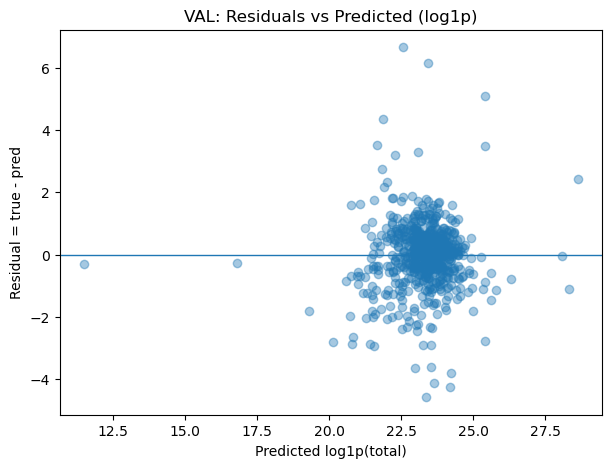

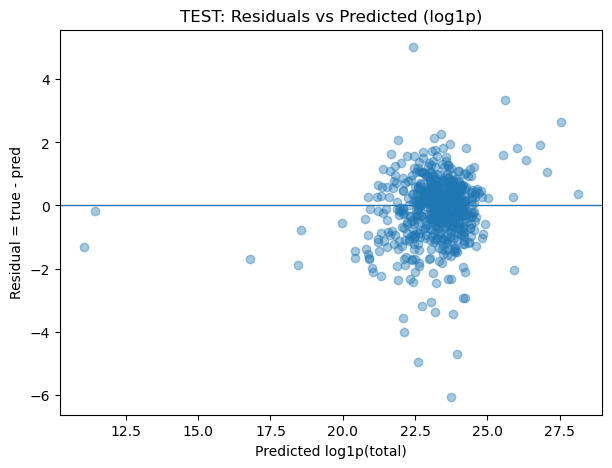

In [50]:
def plot_residuals(model, X, y, title="Residuals vs Predicted (log1p space)"):
    y_pred = model.predict(X, iteration_range=(0, model.best_iteration + 1))
    resid = y - y_pred

    plt.figure(figsize=(7,5))
    plt.scatter(y_pred, resid, alpha=0.4)
    plt.axhline(0, linewidth=1)
    plt.xlabel("Predicted log1p(total)")
    plt.ylabel("Residual = true - pred")
    plt.title(title)
    plt.show()

plot_residuals(bst, dval, y_val_log, "VAL: Residuals vs Predicted (log1p)")
plot_residuals(bst, dtest, y_test_log, "TEST: Residuals vs Predicted (log1p)")

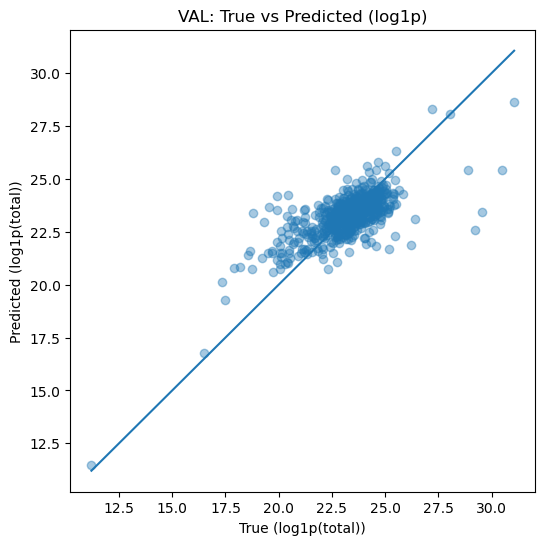

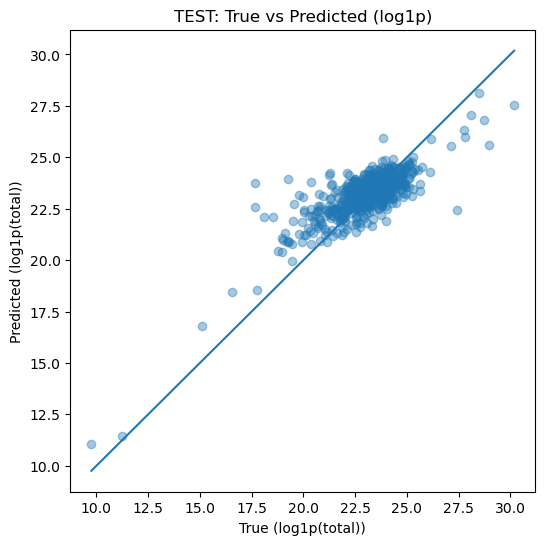

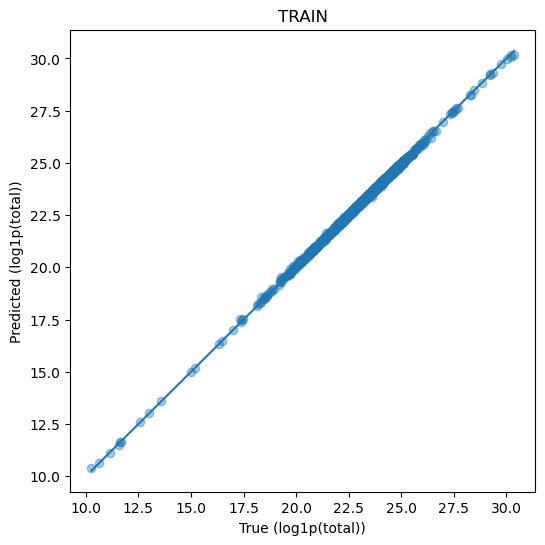

In [51]:
def scatter_true_vs_pred(model, X, y, title="True vs Predicted (log1p space)"):
    y_pred = model.predict(X, iteration_range=(0, model.best_iteration + 1))

    plt.figure(figsize=(6, 6))
    plt.scatter(y, y_pred, alpha=0.4)
    lo = min(y.min(), y_pred.min())
    hi = max(y.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi])  
    plt.xlabel("True (log1p(total))")
    plt.ylabel("Predicted (log1p(total))")
    plt.title(title)
    plt.show()

scatter_true_vs_pred(bst, dval, y_val_log, "VAL: True vs Predicted (log1p)")
scatter_true_vs_pred(bst, dtest, y_test_log, "TEST: True vs Predicted (log1p)")
scatter_true_vs_pred(bst, dtrain, y_train_log, "TRAIN")

# Feature Engineering

After trying the 5 different models, we found that XGBoost had the best results. So, the following attempts at improving model performance using feature enigeering was done on the best XGBoost model.

## Prevelance Filtering

In [54]:
def apply_prevalence_filter(X_train, X_val, X_test, min_prev=0.01):
    prev = (X_train > 0).mean(axis=0)          
    keep = prev >= min_prev

    X_train_f = X_train.loc[:, keep]
    X_val_f   = X_val.loc[:, keep]
    X_test_f  = X_test.loc[:, keep]

    min_samples = int(np.ceil(min_prev * X_train.shape[0]))
    print(f"min_prev={min_prev:.4f} ({min_prev*100:.1f}%) -> kept "
          f"{keep.sum()}/{X_train.shape[1]} features "
          f"(requires >= {min_samples} nonzero TRAIN samples)")
    return X_train_f, X_val_f, X_test_f

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "seed": RANDOM_STATE,
    "verbosity": 1,

    "max_depth": 5,
    "min_child_weight": 5.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 5.0,

    "eta": 0.02,
    "gamma": 0.001,
    "alpha": 0.1,
}

num_boost_round = 30000
early_stopping_rounds = 300

for min_prev in [0.001, 0.01, 0.05, 0.1]:
    print("\n" + "="*60)
    Xtr_f, Xv_f, Xt_f = apply_prevalence_filter(X_train_comp, X_val_comp, X_test_comp, min_prev=min_prev)
    
    dtrain_f = xgb.DMatrix(Xtr_f, label=y_train_log)
    dval_f   = xgb.DMatrix(Xv_f,   label=y_val_log)
    dtest_f  = xgb.DMatrix(Xt_f,  label=y_test_log)

    bst = xgb.train(
        params=params,
        dtrain=dtrain_f,
        num_boost_round=num_boost_round,
        evals=[(dtrain_f, "train"), (dval_f, "val")],
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=200,
    )
    
    best_ntree = bst.best_iteration + 1
    bst_best = bst[:best_ntree]

    eval_split_xgboost("Train", dtrain_f, y_train_log)
    eval_split_xgboost("Val  ", dval_f,   y_val_log)
    eval_split_xgboost("Test ", dtest_f,  y_test_log)


min_prev=0.0010 (0.1%) -> kept 1148/1148 features (requires >= 2 nonzero TRAIN samples)
[0]	train-rmse:1.64345	val-rmse:1.56500
[200]	train-rmse:0.71685	val-rmse:1.16213
[400]	train-rmse:0.43090	val-rmse:1.13730
[600]	train-rmse:0.27236	val-rmse:1.12977
[800]	train-rmse:0.17490	val-rmse:1.12824
[1000]	train-rmse:0.11074	val-rmse:1.12585
[1200]	train-rmse:0.07046	val-rmse:1.12514
[1400]	train-rmse:0.04503	val-rmse:1.12446
[1600]	train-rmse:0.02932	val-rmse:1.12439
[1800]	train-rmse:0.01946	val-rmse:1.12415
[2000]	train-rmse:0.01404	val-rmse:1.12405
[2200]	train-rmse:0.01301	val-rmse:1.12401
[2400]	train-rmse:0.01265	val-rmse:1.12402
[2560]	train-rmse:0.01251	val-rmse:1.12402
Train: R2=1.000  RMSE=0.013  MAE=0.009
Val  : R2=0.491  RMSE=1.124  MAE=0.775
Test : R2=0.622  RMSE=1.038  MAE=0.726

min_prev=0.0100 (1.0%) -> kept 1141/1148 features (requires >= 20 nonzero TRAIN samples)
[0]	train-rmse:1.64379	val-rmse:1.56517
[200]	train-rmse:0.71744	val-rmse:1.16471
[400]	train-rmse:0.43155	va

## Variance Filtering

In [55]:
def variance_quantile_filter(X_train, X_val, X_test, keep_frac=0.9):
    var = X_train.var(axis=0)
    cutoff = var.quantile(1 - keep_frac)
    keep = var >= cutoff
    print(f"keep_frac={keep_frac:.2f} -> kept {keep.sum()}/{X_train.shape[1]} features (cutoff={cutoff:.2e})")
    return X_train.loc[:, keep], X_val.loc[:, keep], X_test.loc[:, keep], keep

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "seed": RANDOM_STATE,
    "verbosity": 1,

    "max_depth": 5,
    "min_child_weight": 5.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 5.0,

    "eta": 0.02,
    "gamma": 0.001,
    "alpha": 0.1,
}

num_boost_round = 30000
early_stopping_rounds = 300

for keep_frac in [0.95, 0.9, 0.8, 0.7]:
    print("\n" + "="*60)
    Xtr_f, Xv_f, Xt_f, keep = variance_quantile_filter(X_train_comp, X_val_comp, X_test_comp, keep_frac=keep_frac)
    
    dtrain_f = xgb.DMatrix(Xtr_f, label=y_train_log)
    dval_f   = xgb.DMatrix(Xv_f,   label=y_val_log)
    dtest_f  = xgb.DMatrix(Xt_f,  label=y_test_log)

    bst = xgb.train(
        params=params,
        dtrain=dtrain_f,
        num_boost_round=num_boost_round,
        evals=[(dtrain_f, "train"), (dval_f, "val")],
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=200,
    )
    
    best_ntree = bst.best_iteration + 1
    bst_best = bst[:best_ntree]

    eval_split_xgboost("Train", dtrain_f, y_train_log)
    eval_split_xgboost("Val  ", dval_f,   y_val_log)
    eval_split_xgboost("Test ", dtest_f,  y_test_log)


keep_frac=0.95 -> kept 1090/1148 features (cutoff=4.38e-12)
[0]	train-rmse:1.64375	val-rmse:1.56513
[200]	train-rmse:0.71588	val-rmse:1.16004
[400]	train-rmse:0.42983	val-rmse:1.13318
[600]	train-rmse:0.27183	val-rmse:1.12444
[800]	train-rmse:0.17340	val-rmse:1.12306
[1000]	train-rmse:0.10915	val-rmse:1.12117
[1200]	train-rmse:0.06936	val-rmse:1.12019
[1400]	train-rmse:0.04469	val-rmse:1.11950
[1600]	train-rmse:0.02873	val-rmse:1.11946
[1800]	train-rmse:0.01903	val-rmse:1.11925
[2000]	train-rmse:0.01390	val-rmse:1.11925
[2188]	train-rmse:0.01291	val-rmse:1.11925
Train: R2=1.000  RMSE=0.016  MAE=0.011
Val  : R2=0.495  RMSE=1.119  MAE=0.768
Test : R2=0.617  RMSE=1.044  MAE=0.730

keep_frac=0.90 -> kept 1033/1148 features (cutoff=2.75e-11)
[0]	train-rmse:1.64382	val-rmse:1.56521
[200]	train-rmse:0.71876	val-rmse:1.16024
[400]	train-rmse:0.43310	val-rmse:1.13090
[600]	train-rmse:0.27144	val-rmse:1.12305
[800]	train-rmse:0.17218	val-rmse:1.12087
[1000]	train-rmse:0.10929	val-rmse:1.11907
[

## Dominance Features

In [ ]:
def add_dominance_features(X):
    Xv = X.values
    n = X.shape[1]

    sorted_rows = np.sort(Xv, axis=1)[:, ::-1]

    out = pd.DataFrame(index=X.index)
    out["richness"]  = (Xv > 0).sum(axis=1)
    out["top1"]      = sorted_rows[:, 0]
    out["top5_sum"]  = sorted_rows[:, :min(5,n)].sum(axis=1)
    out["top10_sum"] = sorted_rows[:, :min(10,n)].sum(axis=1)
    out["simpson"] = (Xv**2).sum(axis=1)
    eps = 1e-12
    Xpos = Xv + eps
    Xsorted = np.sort(Xpos, axis=1)
    cum = np.cumsum(Xsorted, axis=1)
    out["gini"] = (n + 1 - 2 * (cum.sum(axis=1) / cum[:, -1])) / n

    return out

def add_logit_features(X, eps=1e-6):
    out = pd.DataFrame(index=X.index)
    top1 = X.max(axis=1)
    top5 = np.sort(X.values, axis=1)[:, ::-1][:, :5].sum(axis=1)

    out["logit_top1"] = np.log((top1 + eps) / (1 - top1 + eps))
    out["logit_top5"] = np.log((top5 + eps) / (1 - top5 + eps))
    return out


dom_train = add_dominance_features(X_train_comp)
dom_val   = add_dominance_features(X_val_comp)
dom_test  = add_dominance_features(X_test_comp)

logit_train = add_logit_features(X_train_comp)
logit_val = add_logit_features(X_val_comp)
logit_test = add_logit_features(X_test_comp)

X_train_aug = pd.concat([X_train_comp, dom_train, logit_train], axis=1)
X_val_aug   = pd.concat([X_val_comp, dom_val, logit_val], axis=1)
X_test_aug  = pd.concat([X_test_comp, dom_test, logit_test], axis=1)


params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "seed": RANDOM_STATE,
    "verbosity": 1,

    "max_depth": 5,
    "min_child_weight": 5.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 5.0,

    "eta": 0.02,
    "gamma": 0.001,
    "alpha": 0.1,
}

num_boost_round = 30000
early_stopping_rounds = 300

dtrain_aug = xgb.DMatrix(X_train_aug, label=y_train_log)
dval_aug   = xgb.DMatrix(X_val_aug,   label=y_val_log)
dtest_f  = xgb.DMatrix(X_test_aug,  label=y_test_log)

bst = xgb.train(
    params=params,
    dtrain=dtrain_aug,
    num_boost_round=num_boost_round,
    evals=[(dtrain_aug, "train"), (dval_aug, "val")],
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=200,
)

best_ntree = bst.best_iteration + 1
bst_best = bst[:best_ntree]

eval_split_xgboost("Train", dtrain_aug, y_train_log)
eval_split_xgboost("Val  ", dval_aug,   y_val_log)
eval_split_xgboost("Test ", dtest_aug,  y_test_log)

## Add Summary Statistics as Features

In [44]:
LABEL_COL = "total"
EPS = 1e-6
RANDOM_STATE = 42

def clr_transform(rel, eps=1e-6):
    X = np.asarray(rel, dtype=np.float64)
    X = np.clip(X, eps, None)
    logX = np.log(X)
    return logX - logX.mean(axis=1, keepdims=True)

def build_X(comp_df, count_df, feature_cols, eps=1e-6):
    rel = comp_df.reindex(columns=feature_cols, fill_value=0.0).to_numpy(np.float64)
    counts = count_df.reindex(columns=feature_cols, fill_value=0.0).to_numpy(np.float64)

    lib = counts.sum(axis=1)
    X1 = clr_transform(rel, eps=eps)
    X2 = np.log1p(counts) - np.log1p(lib).reshape(-1, 1)
    X3 = np.log1p(lib).reshape(-1, 1)

    X4 = (counts > 0).astype(np.float32)
    X5 = np.log1p(counts) 

    return np.hstack([X1, X2, X3, X4, X5])

feature_cols = X_train_comp.columns

X_train = build_X(X_train_comp, X_train_count, feature_cols, eps=EPS)
X_val   = build_X(X_val_comp, X_val_count,   feature_cols, eps=EPS)
X_test  = build_X(X_test_comp, X_test_count,  feature_cols, eps=EPS)

dtrain = xgb.DMatrix(X_train, label=y_train_log)
dval   = xgb.DMatrix(X_val,   label=y_val_log)
dtest  = xgb.DMatrix(X_test,  label=y_test_log)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "seed": RANDOM_STATE,
    "verbosity": 1,

    "max_depth": 5,
    "min_child_weight": 10.0,
    "subsample": 0.8,
    "colsample_bytree": 0.5,
    "lambda": 10.0,
    "subsample": 0.7,

    "eta": 0.02,
    "gamma": 0.01,
    "alpha": 0.1,
}

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=30000,
    evals=[(dval, "val")],
    early_stopping_rounds=300,
    verbose_eval=False,
)

best_ntree = bst.best_iteration + 1
bst_best = bst[:best_ntree]

print("Best iteration:", bst.best_iteration, "| Using trees:", best_ntree)

eval_split_xgboost("Train", dtrain, y_train_log)
eval_split_xgboost("Val  ", dval,   y_val_log)
eval_split_xgboost("Test ", dtest,  y_test_log)

X shapes: (1910, 4593) (637, 4593) (637, 4593) | expected dim: 2297
Best iteration: 1800 | Using trees: 1801
Train: R2=0.999  RMSE=0.038  MAE=0.025
Val  : R2=0.515  RMSE=1.097  MAE=0.757
Test : R2=0.639  RMSE=1.013  MAE=0.719
